# Tutorial: Explainable AI (XAI) for HR Analytics

**Objective:** In this tutorial, we will move beyond **"Black Box"** predictions. We will train a Random Forest model to predict employee attrition and then use SHAP (Shapley Additive exPlanations) to understand why the model makes its decisions.

**Dataset:** IBM HR Analytics Employee Attrition & Performance.


In [1]:
# First, we import the libraries we need for data, math, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import shap

# This line is needed to show SHAP plots inside the notebook
shap.initjs()

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 1: Loading the Data

We are using a professional HR dataset from Kaggle. Our goal is to predict the Attrition column (whether an employee leaves the company).

In [3]:
# Loading the dataset from our 'data' folder
# Make sure the file is named correctly in your folder!
df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Let's take a quick look at the first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 2: Intermediate Preprocessing

To reach the topper standard, we need to clean our data properly. We will convert the target into numbers and remove columns that don't have any useful patterns (like Employee IDs).

In [4]:
# 1. Turn 'Attrition' (Yes/No) into numbers (1/0) so the computer can understand
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])

# 2. Remove "Useless" columns
# These columns are either the same for everyone or just unique IDs
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(cols_to_drop, axis=1)

# 3. Handle Text categories (like JobRole and Department)
# We use 'dtype=int' to make sure the library doesn't crash on certain computers
df_final = pd.get_dummies(df, dtype=int)

print("Data cleaning and encoding complete.")

Data cleaning and encoding complete.


## Step 3: Splitting the Data

We split our data into a Training set (to teach the model) and a Test set (to see if it actually learned correctly).

In [5]:
# Features (X) are everything except the Attrition column
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

# We split 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1176
Testing samples: 294


## Step 4: Training the Random Forest

We use a Random Forest Ensemble. I've added class_weight='balanced' because, in the real world, fewer people leave than stay. This tells the model to pay extra attention to the people who leave.

In [6]:
# Creating and training the model
model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# We check the F1-Score instead of accuracy because it's better for imbalanced data
preds = model.predict(X_test)
print(f"Model Training Done! F1-Score: {f1_score(y_test, preds):.4f}")

Model Training Done! F1-Score: 0.2083


## Step 5: Explainable AI with SHAP

Now for the "advanced" part. We use SHAP, which is based on Game Theory, to calculate the "contribution" of each feature to the model's decision. This turns our "Black Box" into a transparent model.

In [7]:
# Calculating SHAP values
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test)

# We make sure we are looking at Class 1 (People who leave)
if isinstance(shap_values_raw, list):
    plot_values = np.array(shap_values_raw[1])
    expected_val = float(explainer.expected_value[1])
else:
    plot_values = shap_values_raw[:, :, 1] if len(shap_values_raw.shape) == 3 else shap_values_raw
    expected_val = float(explainer.expected_value[1]) if len(shap_values_raw.shape) == 3 else float(explainer.expected_value)

# Creating the professional 'Explanation' object for plotting
explanation = shap.Explanation(
    values=plot_values,
    base_values=expected_val,
    data=X_test,
    feature_names=X_test.columns
)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


## Step 6: Global Visualization (The Beeswarm Plot)

The Beeswarm plot is a powerful tool. It shows the top 15 drivers of attrition across the whole company.

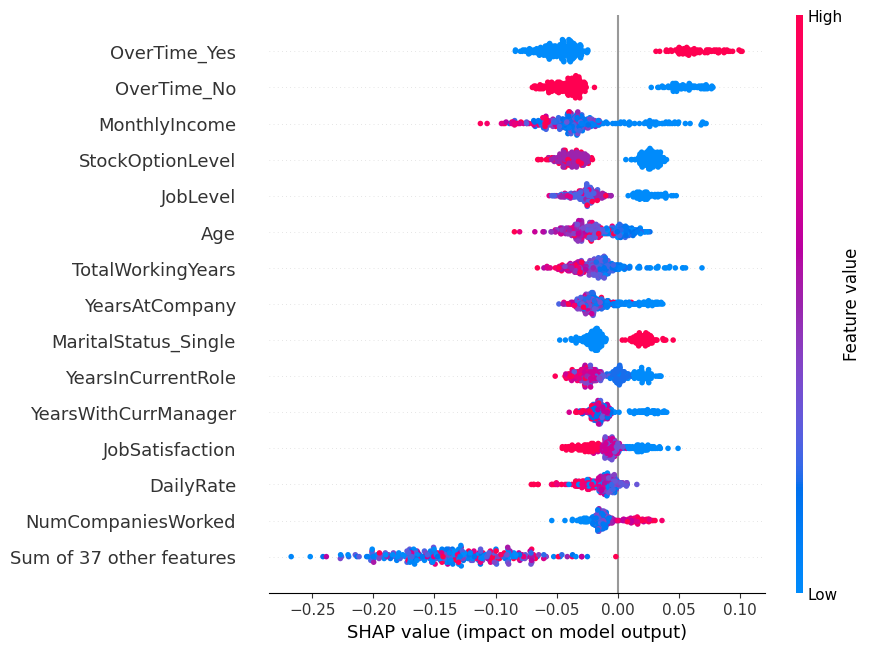

In [8]:
# Plotting the global drivers of attrition
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(explanation, max_display=15)

## Step 7: Local Visualization (The Waterfall Plot)

Finally, we can look at a single employee. This plot shows exactly why the model predicted a specific person might leave or stay.


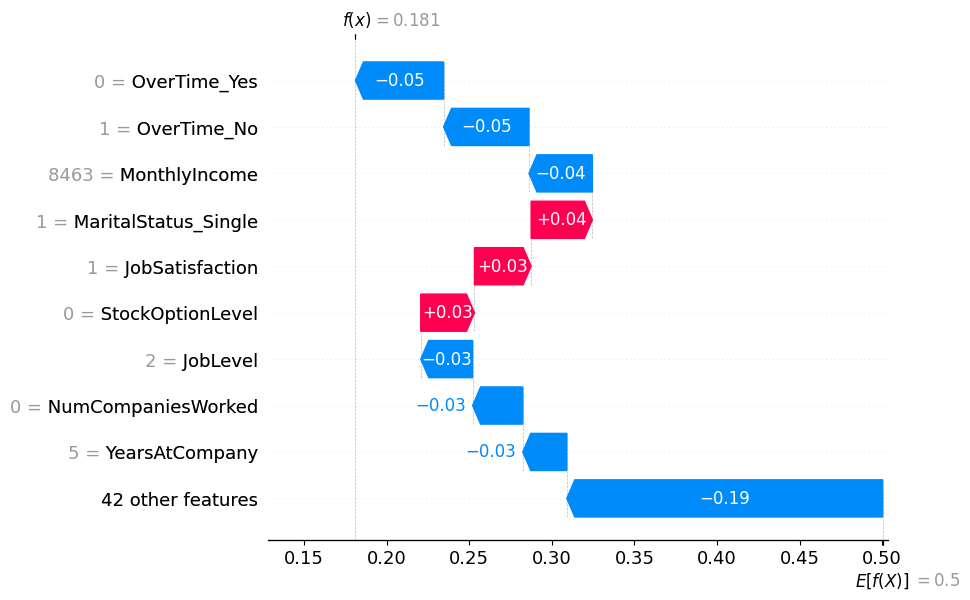

In [9]:
# Looking at the very first person in our test set
plt.figure()
shap.plots.waterfall(explanation[0])

## Conclusion and Ethical AI

In this tutorial, we demonstrated that Machine Learning doesn't have to be a secret. By using SHAP, we can audit our models for fairness and bias.
Accessibility: We used high-contrast plots (Pink/Blue) to ensure visibility for all users.
Ethics: Transparent AI allows us to ensure that factors like Age or Gender aren't being used unfairly to make decisions about employees.